In [1]:
import sys
sys.path.append('..')
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model_rate_based import CANN_DDM_model
#from make_conn_mat import make_edge_conn_mat, make_bump_conn_mat
from make_conn_mat_updated import make_conn_mat_from_kernel
from tqdm import tqdm
import pickle
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

In [2]:
num = 1024
edge_pop = {'num_E': 1024, 'tau_E': 2, 'c_EB': 5,
             'alpha_E': 1, 'sigma_E': 10, 'clamp_frac_E': 0.1, 
            'edge_type': 'tanh', 'offset': 0.0, 'optimize_offset': False,
            'k0':512}
#-0.006176
bump_pop = {'num_B': 1024, 'tau_B': .5, 'c_BE': 1,
            'beta_B': 4,
            'c_BE_params': {'mode': 'const'}, 
            'sigma_B': 0.1, 'clamp_frac_B': 0.1}

decision_space_params = {'t_start': 200, 'boundary': 1, 'drift_rate': 1, 
                         'noise_scale': 0.1, 'dt_DDM': 1., 'x0': 0.5, 
                         'dur1': 100, 'dur2': 1000, 'seed': 4}


CANN_params = {'edge_pop': edge_pop, 'bump_pop': bump_pop, 'decision_space_params': decision_space_params}
model = CANN_DDM_model(CANN_params = CANN_params)

In [ ]:
num = 1024
edge_pop = {'num_E': 1024, 'tau_E': 2, 'c_EB': 5,
             'alpha_E': 1, 'sigma_E': 10, 'clamp_frac_E': 0.1, 
            'edge_type': 'tanh', 'offset': 0.0, 'optimize_offset': False}
#-0.006176
bump_pop = {'num_B': 1024, 'tau_B': .5, 'c_BE': 1,
            'beta_B': 4,
            'c_BE_params': {'mode': 'const'}, 
            'sigma_B': 0.1, 'clamp_frac_B': 0.1}

decision_space_params = {'t_start': 200, 'boundary': 1, 'drift_rate': 1, 
                         'noise_scale': 0.1, 'dt_DDM': 1., 'x0': 0.5, 
                         'dur1': 100, 'dur2': 1000, 'seed': 4}


CANN_params = {'edge_pop': edge_pop, 'bump_pop': bump_pop, 'decision_space_params': decision_space_params}
model = CANN_DDM_model(CANN_params = CANN_params)

In [ ]:
pos_offset = 0
t0 = 10
t1 = 200
t2 = 400
c_BE = 0.3
c_EB = 0.3
color_bump = "#716db2"
color_edge = "#1d52a1"

bump_pop.update({'c_BE': c_BE})
edge_pop.update({'c_EB': c_EB})
CANN_params.update({'bump_pop': bump_pop, 'edge_pop': edge_pop})
model = CANN_DDM_model(CANN_params = CANN_params)
t_start = int(model.t_start)
model.cue_R_all[t_start:t_start+t1] = 1
model.cue_R_all[t_start+t1:t_start+t2] = 0
model.cue_L_all[t_start:t_start+t1] = 0
model.cue_L_all[t_start+t1:t_start+t2] = 1
runner = model.run_simulation(mon_vars = ['r_E', 'r_B', 'I_BE', 'I_EB', 'theta_E', 'theta_B'], pos_offset=pos_offset, get_RT=False)


  0%|          | 0/1100 [00:00<?, ?it/s]

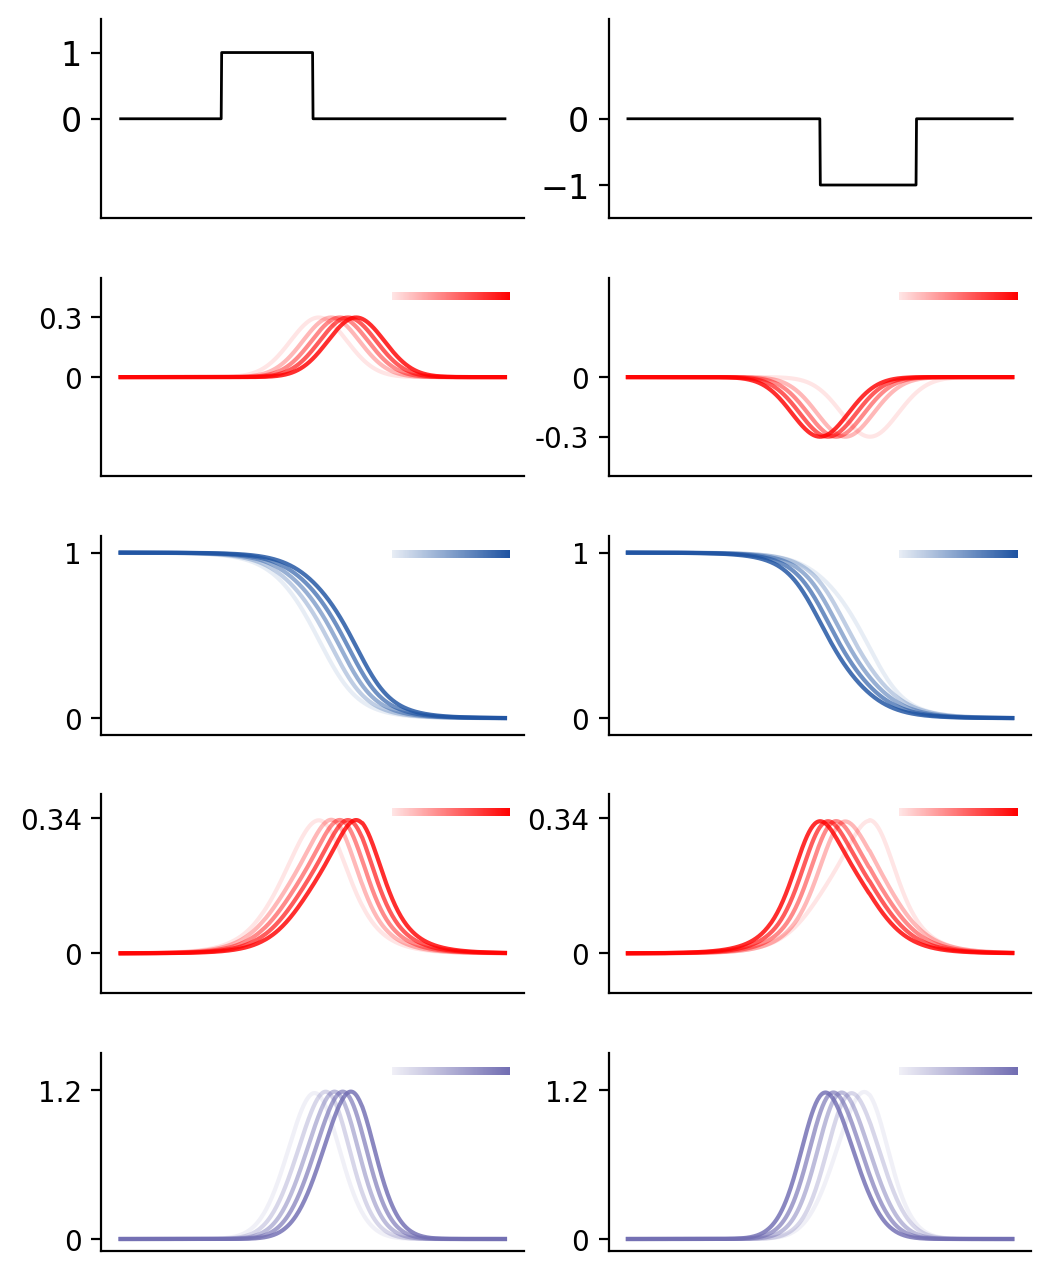

In [32]:
# Helper: add alpha gradient colorbar in upper-right of subplot (acts as label)
from matplotlib.colors import to_rgb, ListedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_alpha_colorbar(ax, base_color, label=None):
    """Add a small horizontal alpha bar (0.1->1) in the upper-right corner."""
    rgb = np.array(to_rgb(base_color))
    alphas = np.linspace(0.1, 1.0, 256)
    colors = np.zeros((256, 4))
    colors[:, :3] = rgb
    colors[:, 3] = alphas
    cmap = ListedColormap(colors)
    norm = plt.Normalize(0.1, 1.0)

    # Use a horizontal inset bar at the upper-right of each subplot.
    cax = inset_axes(ax, width="28%", height="4%", loc='upper right', borderpad=0.5)
    cb = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation='horizontal')

    # Remove colorbar axis decorations; keep only the gradient strip.
    cb.set_ticks([])
    cb.outline.set_visible(False)
    cax.set_xticks([])
    cax.set_yticks([])
    for spine in cax.spines.values():
        spine.set_visible(False)

    if label is not None:
        cax.text(1.02, 0.5, label, transform=cax.transAxes, va='center', ha='left', fontsize=8)

fig, ax = plt.subplots(5, 2, figsize=(6, 8))
t_val = np.arange(0, 800)
neural_range = np.arange(312, 712)
for col in range(2):
    # row 1: cue scheme
    if col == 0:
        cue_val = 1
        y = np.zeros_like(t_val)
        y[t_start+t0:t_start+t1] = cue_val
        ax[0, col].plot(t_val, y, color="black", linewidth=1)
        ax[0, col].tick_params(axis='both', which='both', labelsize=12)
        ax[0, col].set_xticks([t_start+t0, t_start+t1], [r'$t_0$', r'$t_1$'], fontsize=16)
        ax[0, col].set_yticks([0, 1])
        ax[0, col].set_ylim(-1.5,1.5)
        
    if col == 1:
        cue_val = -1
        y = np.zeros_like(t_val)
        y[t_start+t1:t_start+t2] = cue_val
        ax[0, col].plot(t_val, y, color="black", linewidth=1)
        ax[0, col].tick_params(axis='both', which='both', labelsize=12)
        ax[0, col].set_xticks([t_start+t1, t_start+t2], [r'$t_1$', r'$t_2$'], fontsize=16)
        ax[0, col].set_yticks([-1, 0])
        ax[0, col].set_ylim(-1.5, 1.5)
        
    # row 2: I_BE
    for idx, t in enumerate(range(
            t_start+t0 if col == 0 else t_start+t1, 
            t_start+t1 if col == 0 else t_start+t2, 
            40)):
        ax[1, col].plot(runner.mon.I_BE[t,neural_range], color='red', alpha = 0.1 + 0.9*idx/5)
        I_BE_max = np.round(np.max(runner.mon.I_BE[t,neural_range]), 2)
        I_BE_min = np.round(np.min(runner.mon.I_BE[t,neural_range]), 2)
        if col == 0:
            ax[1, col].set_yticks([0, I_BE_max], [0, I_BE_max])
        else:
            ax[1, col].set_yticks([I_BE_min, 0], [I_BE_min, 0])
        ax[1, col].set_ylim(-0.5, 0.5)
        #ax[1, col].set_title(r'$I_{\text{BE}}$', fontsize=16, y=0.9)
    add_alpha_colorbar(ax[1, col], base_color='red')
    
    # row 3: r_E
    for idx, t in enumerate(range(
            t_start+t0 if col == 0 else t_start+t1, 
            t_start+t1 if col == 0 else t_start+t2, 
            40)):
        ax[2, col].plot(runner.mon.r_E[t,neural_range], color=color_edge, alpha = 0.1 + 0.9*idx/5)
        ax[2, col].set_ylim(-0.1, 1.1)
        ax[2, col].set_yticks([0, 1])
    add_alpha_colorbar(ax[2, col], base_color=color_edge)

    # row 4: I_EB
    for idx, t in enumerate(range(
            t_start+t0 if col == 0 else t_start+t1, 
            t_start+t1 if col == 0 else t_start+t2, 
            40)):
        ax[3, col].plot(runner.mon.I_EB[t,neural_range], color='red', alpha = 0.1 + 0.9*idx/5)
        I_EB_max = np.round(np.max(runner.mon.I_EB[t,neural_range]),2)
        ax[3, col].set_ylim(-0.1, 0.4)
        ax[3, col].set_yticks([0, 0.34], [0, 0.34])
    add_alpha_colorbar(ax[3, col], base_color='red')

    # row 5: r_B
    for idx, t in enumerate(range(
            t_start+t0 if col == 0 else t_start+t1, 
            t_start+t1 if col == 0 else t_start+t2, 
            40)):
        ax[4, col].plot(runner.mon.r_B[t,neural_range], color=color_bump, alpha = 0.1 + 0.9*idx/5)
        ax[4, col].set_ylim(-0.1, 1.5)
        r_B_max = np.round(np.max(runner.mon.r_B[t,neural_range]), 1)
        ax[4, col].set_yticks([0, r_B_max], [0, r_B_max])
    add_alpha_colorbar(ax[4, col], base_color=color_bump)

fig.subplots_adjust(hspace=0.3)

for axis in ax.flat:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(right=False, labelbottom=False, bottom=False, top=False)

fig.savefig('../figures/figure2/fig2_micro_dyn.png', dpi=300)

In [140]:
t

560